# Adversarial-Attack Framework: Fast Gradient Sign Method (FGSM) and Projected Gradient Descent (PGD)
## Version 1: CICIoT2023 | 2,000 Training (Weighted) | Batch Size 256 | 10 Epochs | LR 0.05 | Seed 42 
## Target (y) = "label_multiclass" | Data Reupload = 2

## Setup

In [1]:
%pip install -q pennylane pyarrow fastparquet

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pennylane as qp
from pennylane import numpy as np
import torch
import torch.nn as nn

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import f1_score, confusion_matrix, classification_report

import sys
from pathlib import Path
import json
import time
from collections import Counter

In [3]:
DATA_ROOT = Path("/kaggle/input/datasets/lawunnannda/quantum-sentinel-iot-v1-0")
data_path = f"{DATA_ROOT}/CICIoT2023/quantum"
target_col = "label_multiclass"

SCRIPTS_ROOT = Path("/kaggle/input/datasets/lawunnannda/quantum-sentinel-scripts")
sys.path.insert(0, str(SCRIPTS_ROOT))

log_dir = "/kaggle/working/logs"
Path(f"{log_dir}").mkdir(parents=True, exist_ok=True)

In [4]:
from scripts.constants import DEFAULT_NOISE_RATE
from scripts.data import (
    class_balance_table,
    load_split,
    plot_class_balance_pie,
    plot_class_balance_bars,
    stratified_head,
)
from scripts.circuit import build_forward_circuit, create_quantum_device, initialize_weights
from scripts.loss import compute_l_ce
from scripts.logging import write_history_log
from scripts.inference import predict_labels
from scripts.attacks import fgsm_attack, pgd_attack, eval_attacked
from scripts.utils import expectations_to_tensor, get_torch_device, to_np_x, to_torch_x

In [5]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available?: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA device name: {torch.cuda.get_device_name(0)}")
    print(f"Current CUDA device index: {torch.cuda.current_device()}")

PyTorch version: 2.10.0+cu128
CUDA available?: True
CUDA device name: Tesla T4
Current CUDA device index: 0


## Load Dataset: CICIoT2023

In [6]:
df = pd.read_parquet(f"{data_path}/q8_train.parquet")
df

,n_pkts_total,duration,pkt_size_max,pkt_size_std,pkt_size_mean,n_bytes_total,pkt_size_min,protocol,label_multiclass,label_binary,label_family
0,0.032581,0.003637,0.125064,0.017957,1.419705e-01,1.057962,0.178744,3.141593,DDoS-RSTFINFlood,1,ddos
1,2.204835,0.378237,1.097552,1.699442,6.532626e-01,1.142228,0.322069,0.374114,BenignTraffic,0,benign
2,0.000000,0.000000,0.000000,0.000000,5.621659e-16,0.944141,0.000000,1.048536,DDoS-ICMP_Flood,1,ddos
3,0.000000,0.000071,0.298669,0.679082,1.579194e-01,1.075915,0.178744,3.141593,DDoS-TCP_Flood,1,ddos
4,0.009310,0.000000,0.122890,0.000000,1.419705e-01,1.057771,0.178744,3.141593,DDoS-RSTFINFlood,1,ddos
...,...,...,...,...,...,...,...,...,...,...,...
132161,0.000000,0.017165,0.085190,0.000000,9.831928e-02,1.022967,0.123910,1.238534,DDoS-UDP_Flood,1,ddos
132162,0.009243,0.000000,0.126688,0.033338,1.422353e-01,1.058106,0.178744,0.362070,DDoS-RSTFINFlood,1,ddos
132163,0.000000,0.092489,0.085190,0.000000,9.831928e-02,1.022967,0.123910,1.238534,DDoS-UDP_Flood,1,ddos
132164,0.009310,0.000000,0.122890,0.000000,1.419705e-01,1.057771,0.178744,3.141593,DDoS-RSTFINFlood,1,ddos


In [7]:
print(df["label_multiclass"].unique())
print()
print(df["label_family"].unique())

['DDoS-RSTFINFlood' 'BenignTraffic' 'DDoS-ICMP_Flood' 'DDoS-TCP_Flood'
 'DDoS-SynonymousIP_Flood' 'DDoS-SlowLoris' 'DDoS-PSHACK_Flood'
 'DoS-TCP_Flood' 'DDoS-UDP_Flood' 'DoS-UDP_Flood' 'DoS-HTTP_Flood'
 'DDoS-SYN_Flood' 'DoS-SYN_Flood' 'MITM-ArpSpoofing'
 'DictionaryBruteForce' 'DNS_Spoofing' 'DDoS-UDP_Fragmentation'
 'Recon-PortScan' 'VulnerabilityScan' 'XSS' 'DDoS-HTTP_Flood'
 'DDoS-ICMP_Fragmentation' 'DDoS-ACK_Fragmentation' 'Recon-HostDiscovery'
 'Recon-OSScan' 'BrowserHijacking' 'Recon-PingSweep' 'SqlInjection'
 'Backdoor_Malware' 'CommandInjection' 'Uploading_Attack']

['ddos' 'benign' 'dos' 'spoofing_mitm' 'bruteforce_password' 'recon'
 'web_injection' 'backdoor_malware_ransomware']


In [8]:
# check rows if NaN dropped
df[df[target_col].notna()].copy()

,n_pkts_total,duration,pkt_size_max,pkt_size_std,pkt_size_mean,n_bytes_total,pkt_size_min,protocol,label_multiclass,label_binary,label_family
0,0.032581,0.003637,0.125064,0.017957,1.419705e-01,1.057962,0.178744,3.141593,DDoS-RSTFINFlood,1,ddos
1,2.204835,0.378237,1.097552,1.699442,6.532626e-01,1.142228,0.322069,0.374114,BenignTraffic,0,benign
2,0.000000,0.000000,0.000000,0.000000,5.621659e-16,0.944141,0.000000,1.048536,DDoS-ICMP_Flood,1,ddos
3,0.000000,0.000071,0.298669,0.679082,1.579194e-01,1.075915,0.178744,3.141593,DDoS-TCP_Flood,1,ddos
4,0.009310,0.000000,0.122890,0.000000,1.419705e-01,1.057771,0.178744,3.141593,DDoS-RSTFINFlood,1,ddos
...,...,...,...,...,...,...,...,...,...,...,...
132161,0.000000,0.017165,0.085190,0.000000,9.831928e-02,1.022967,0.123910,1.238534,DDoS-UDP_Flood,1,ddos
132162,0.009243,0.000000,0.126688,0.033338,1.422353e-01,1.058106,0.178744,0.362070,DDoS-RSTFINFlood,1,ddos
132163,0.000000,0.092489,0.085190,0.000000,9.831928e-02,1.022967,0.123910,1.238534,DDoS-UDP_Flood,1,ddos
132164,0.009310,0.000000,0.122890,0.000000,1.419705e-01,1.057771,0.178744,3.141593,DDoS-RSTFINFlood,1,ddos


In [9]:
# get labels
class_names = sorted(df[target_col].dropna().unique())
class_names

['Backdoor_Malware',
 'BenignTraffic',
 'BrowserHijacking',
 'CommandInjection',
 'DDoS-ACK_Fragmentation',
 'DDoS-HTTP_Flood',
 'DDoS-ICMP_Flood',
 'DDoS-ICMP_Fragmentation',
 'DDoS-PSHACK_Flood',
 'DDoS-RSTFINFlood',
 'DDoS-SYN_Flood',
 'DDoS-SlowLoris',
 'DDoS-SynonymousIP_Flood',
 'DDoS-TCP_Flood',
 'DDoS-UDP_Flood',
 'DDoS-UDP_Fragmentation',
 'DNS_Spoofing',
 'DictionaryBruteForce',
 'DoS-HTTP_Flood',
 'DoS-SYN_Flood',
 'DoS-TCP_Flood',
 'DoS-UDP_Flood',
 'MITM-ArpSpoofing',
 'Recon-HostDiscovery',
 'Recon-OSScan',
 'Recon-PingSweep',
 'Recon-PortScan',
 'SqlInjection',
 'Uploading_Attack',
 'VulnerabilityScan',
 'XSS']

In [10]:
# load all data
X_train_full, y_train_full = load_split(data_path, "q8_train", target_col, class_names)
X_val_full, y_val_full = load_split(data_path, "q8_val", target_col, class_names)
X_cal_full, y_cal_full = load_split(data_path, "q8_calibration", target_col, class_names)
X_test_full, y_test_full = load_split(data_path, "q8_test", target_col, class_names)

In [11]:
# check shape
[X_train_full.shape, y_train_full.shape], [X_val_full.shape, y_val_full.shape], [X_cal_full.shape, y_cal_full.shape], [X_test_full.shape, y_test_full.shape]

([(132166, 8), (132166,)],
 [(18883, 8), (18883,)],
 [(18883, 8), (18883,)],
 [(18883, 8), (18883,)])

## EDA (Before Class-Weighting)

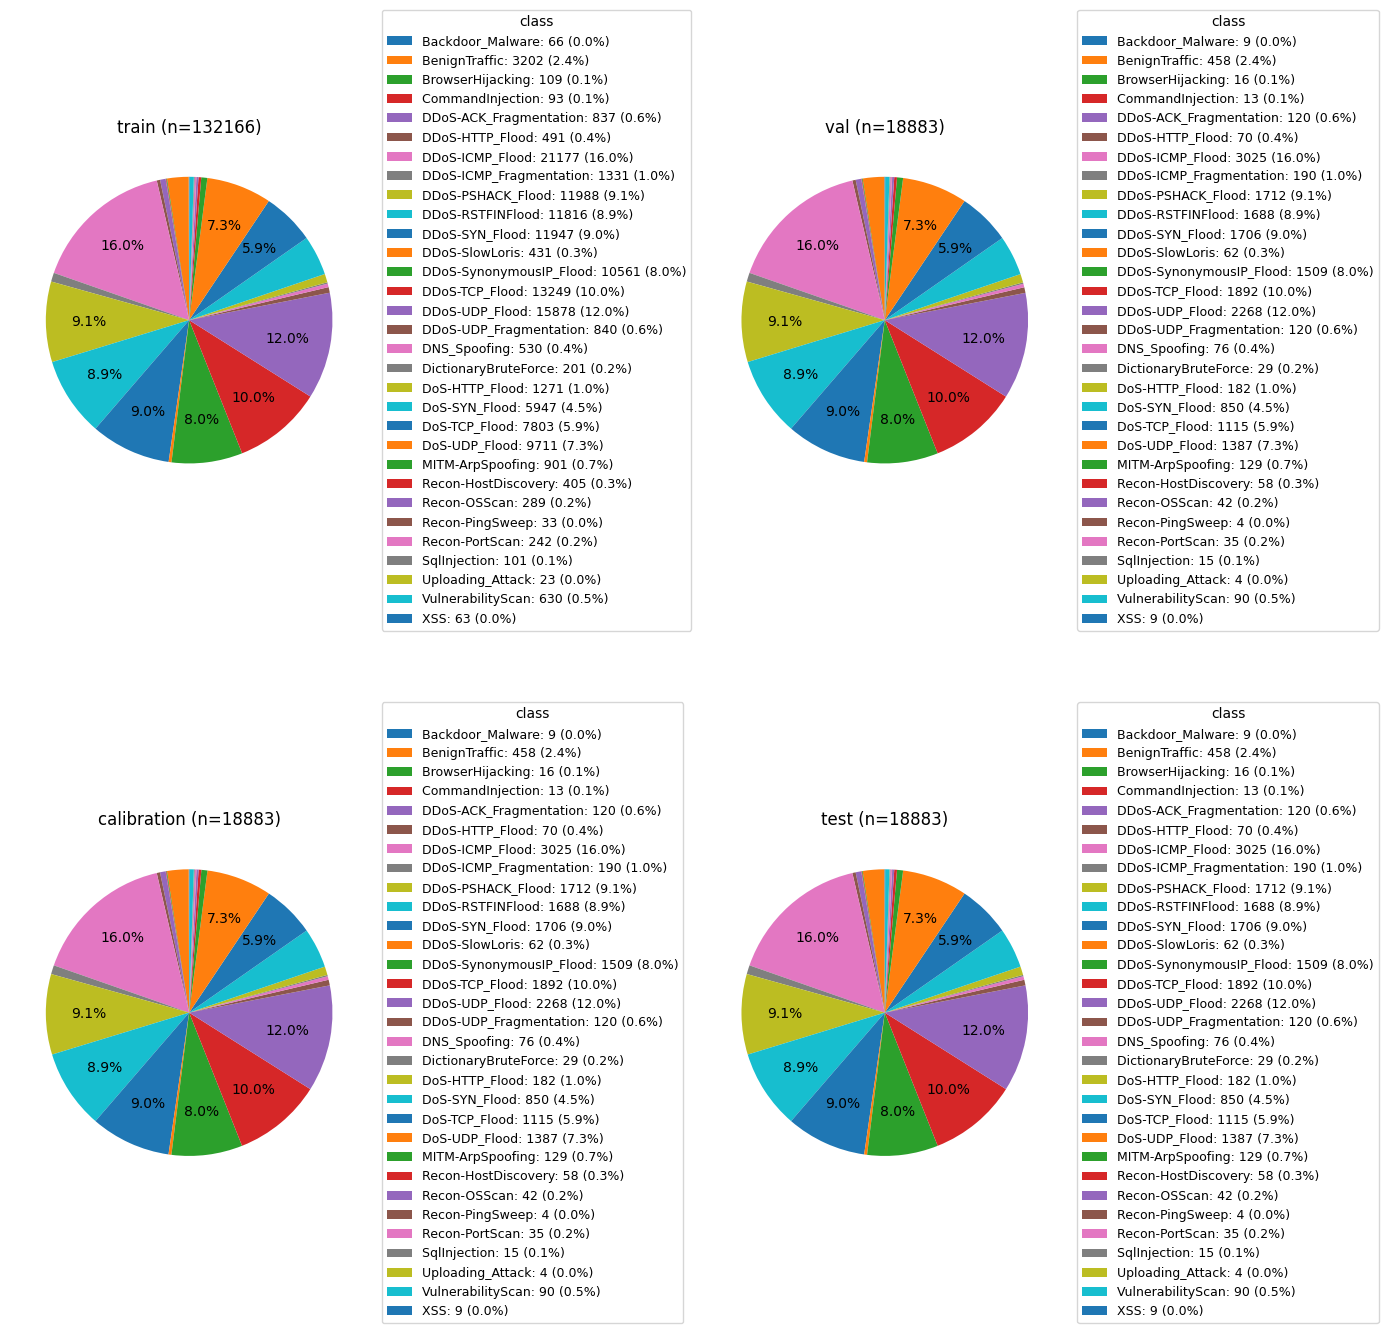

In [12]:
# pie chart
splits = {
    "train": y_train_full,
    "val": y_val_full,
    "calibration": y_cal_full,
    "test": y_test_full,
}

fig, axes = plt.subplots(2, 2, figsize=(14, 14))
for ax, (name, y) in zip(axes.ravel(), splits.items()):
    plot_class_balance_pie(y, class_names, title=f"{name} (n={len(to_np_x(y))})", ax=ax)

plt.tight_layout()
plt.show()

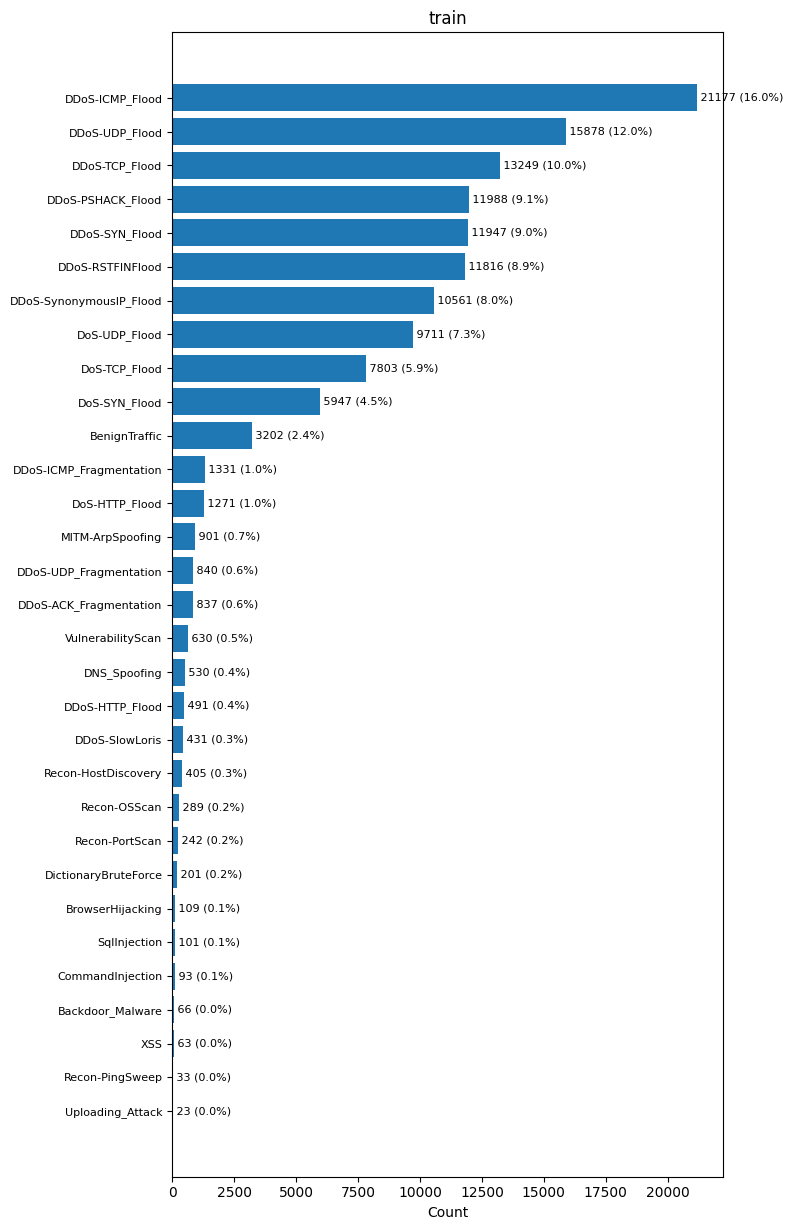

In [13]:
plot_class_balance_bars(y_train_full, class_names, title="train")
plt.show()

## Class Balancing, Data Subset

- Rebalance **training only** (tempered class-weighted CE).
- Keep **val / calibration / test** unchanged (natural distribution).
- Do **not** use hard equal-count undersampling of every class.
- Do **not** use SMOTE after quantum encoding.
- Never train/tune on zero-day.

In [14]:
# tempered class weights for train only: w_c ∝ 1/sqrt(count), clipped
y_np = to_np_x(y_train_full).astype(int)
counts = Counter(y_np.tolist())
raw = {c: 1.0 / (counts[c] ** 0.5) for c in counts}

# normalize to mean 1, then clip
mean_w = sum(raw.values()) / len(raw)
class_weight = {c: min(max(raw[c] / mean_w, 0.25), 4.0) for c in raw}

weight_tensor = torch.tensor(
    [class_weight.get(i, 1.0) for i in range(len(class_names))],
    dtype=torch.float32,
)

print("train class counts:", dict(sorted(counts.items())))
print()
print("tempered class weights:", {class_names[c]: round(class_weight[c], 3) for c in sorted(class_weight)})

train class counts: {0: 66, 1: 3202, 2: 109, 3: 93, 4: 837, 5: 491, 6: 21177, 7: 1331, 8: 11988, 9: 11816, 10: 11947, 11: 431, 12: 10561, 13: 13249, 14: 15878, 15: 840, 16: 530, 17: 201, 18: 1271, 19: 5947, 20: 7803, 21: 9711, 22: 901, 23: 405, 24: 289, 25: 33, 26: 242, 27: 101, 28: 23, 29: 630, 30: 63}

tempered class weights: {'Backdoor_Malware': 2.354, 'BenignTraffic': 0.338, 'BrowserHijacking': 1.831, 'CommandInjection': 1.983, 'DDoS-ACK_Fragmentation': 0.661, 'DDoS-HTTP_Flood': 0.863, 'DDoS-ICMP_Flood': 0.25, 'DDoS-ICMP_Fragmentation': 0.524, 'DDoS-PSHACK_Flood': 0.25, 'DDoS-RSTFINFlood': 0.25, 'DDoS-SYN_Flood': 0.25, 'DDoS-SlowLoris': 0.921, 'DDoS-SynonymousIP_Flood': 0.25, 'DDoS-TCP_Flood': 0.25, 'DDoS-UDP_Flood': 0.25, 'DDoS-UDP_Fragmentation': 0.66, 'DNS_Spoofing': 0.831, 'DictionaryBruteForce': 1.349, 'DoS-HTTP_Flood': 0.536, 'DoS-SYN_Flood': 0.25, 'DoS-TCP_Flood': 0.25, 'DoS-UDP_Flood': 0.25, 'MITM-ArpSpoofing': 0.637, 'Recon-HostDiscovery': 0.95, 'Recon-OSScan': 1.125, 'Rec

In [15]:
# uncomment to take subset
from scripts.data import stratified_head
X_train, y_train = stratified_head(X_train_full, y_train_full, 2000, seed=42)
X_val, y_val = stratified_head(X_train_full, y_train_full, 200, seed=42)
X_cal, y_cal = stratified_head(X_train_full, y_train_full, 200, seed=42)
X_test, y_test = stratified_head(X_train_full, y_train_full, 200, seed=42)

# uncomment to use all
# X_train, y_train = X_train_full, y_train_full
# X_val, y_val = X_val_full, y_val_full
# X_cal, y_cal = X_cal_full, y_cal_full
# X_test, y_test = X_test_full, y_test_full

# recompute tempered weights on the actual training y
y_np = to_np_x(y_train).astype(int)
counts = Counter(y_np.tolist())
raw = {c: 1.0 / (counts[c] ** 0.5) for c in counts}
mean_w = sum(raw.values()) / len(raw)
class_weight = {c: min(max(raw[c] / mean_w, 0.25), 4.0) for c in raw}
weight_tensor = torch.tensor(
    [class_weight.get(i, 1.0) for i in range(len(class_names))],
    dtype=torch.float32,
)

In [16]:
# check shape
[X_train.shape, y_train.shape], [X_val.shape, y_val.shape], [X_cal.shape, y_cal.shape], [X_test.shape, y_test.shape]

([(2000, 8), (2000,)],
 [(200, 8), (200,)],
 [(200, 8), (200,)],
 [(200, 8), (200,)])

## EDA (After Class-Weighting)

In [17]:
num_classes = len(class_names)
num_qubits = X_train.shape[1]

print(f"classes: {class_names}")
print(f"\nnumber of classes: {num_classes}")
print(f"\nnumber of qubits: {num_qubits}")

classes: ['Backdoor_Malware', 'BenignTraffic', 'BrowserHijacking', 'CommandInjection', 'DDoS-ACK_Fragmentation', 'DDoS-HTTP_Flood', 'DDoS-ICMP_Flood', 'DDoS-ICMP_Fragmentation', 'DDoS-PSHACK_Flood', 'DDoS-RSTFINFlood', 'DDoS-SYN_Flood', 'DDoS-SlowLoris', 'DDoS-SynonymousIP_Flood', 'DDoS-TCP_Flood', 'DDoS-UDP_Flood', 'DDoS-UDP_Fragmentation', 'DNS_Spoofing', 'DictionaryBruteForce', 'DoS-HTTP_Flood', 'DoS-SYN_Flood', 'DoS-TCP_Flood', 'DoS-UDP_Flood', 'MITM-ArpSpoofing', 'Recon-HostDiscovery', 'Recon-OSScan', 'Recon-PingSweep', 'Recon-PortScan', 'SqlInjection', 'Uploading_Attack', 'VulnerabilityScan', 'XSS']

number of classes: 31

number of qubits: 8


In [18]:
# initialize devices
dev = qp.device("default.mixed", wires=num_qubits)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [19]:
# convert data type and move to device
X_train = to_torch_x(X_train, device)
y_train = to_torch_x(y_train, device).long()

# move weight tensor to device
weight_tensor = weight_tensor.to(device)

# verify
X_train[:5], y_train[:5], weight_tensor

(tensor([[0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 5.6217e-16, 9.4414e-01,
          0.0000e+00, 1.0485e+00],
         [3.3043e-02, 3.4893e-01, 1.2289e-01, 0.0000e+00, 1.4197e-01, 1.0578e+00,
          1.7874e-01, 3.1416e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 5.6217e-16, 9.4414e-01,
          0.0000e+00, 1.0485e+00],
         [2.3411e-02, 0.0000e+00, 1.2289e-01, 0.0000e+00, 1.4197e-01, 1.0578e+00,
          1.7874e-01, 3.1416e+00],
         [4.3263e-02, 2.9582e-01, 1.2289e-01, 0.0000e+00, 1.4197e-01, 1.0578e+00,
          1.7874e-01, 3.1416e+00]], device='cuda:0'),
 tensor([ 6, 12,  6, 10, 12], device='cuda:0'),
 tensor([2.7227, 0.3930, 1.9253, 2.7227, 0.7551, 1.0291, 0.2500, 0.6088, 0.2500,
         0.2500, 0.2500, 1.0291, 0.2500, 0.2500, 0.2500, 0.7551, 0.9626, 1.5720,
         0.6246, 0.2870, 0.2506, 0.2500, 0.7277, 1.1115, 1.3614, 2.7227, 1.3614,
         1.9253, 1.0000, 0.8610, 2.7227], device='cuda:0'))

In [20]:
# table
splits = {
    "train": y_train,
    "val": y_val,
    "calibration": y_cal,
    "test": y_test,
}

for name, y in splits.items():
    table = class_balance_table(y, class_names)
    print(f"{name} (n={len(to_np_x(y))})")
    display(table)

train (n=2000)


,class,count,pct
0,Backdoor_Malware,1,0.05
1,BenignTraffic,48,2.40
2,BrowserHijacking,2,0.10
3,CommandInjection,1,0.05
4,DDoS-ACK_Fragmentation,13,0.65
5,DDoS-HTTP_Flood,7,0.35
6,DDoS-ICMP_Flood,320,16.00
7,DDoS-ICMP_Fragmentation,20,1.00
8,DDoS-PSHACK_Flood,181,9.05
9,DDoS-RSTFINFlood,179,8.95


val (n=200)


,class,count,pct
0,Backdoor_Malware,0,0.0
1,BenignTraffic,5,2.5
2,BrowserHijacking,0,0.0
3,CommandInjection,0,0.0
4,DDoS-ACK_Fragmentation,1,0.5
5,DDoS-HTTP_Flood,1,0.5
6,DDoS-ICMP_Flood,32,16.0
7,DDoS-ICMP_Fragmentation,2,1.0
8,DDoS-PSHACK_Flood,18,9.0
9,DDoS-RSTFINFlood,18,9.0


calibration (n=200)


,class,count,pct
0,Backdoor_Malware,0,0.0
1,BenignTraffic,5,2.5
2,BrowserHijacking,0,0.0
3,CommandInjection,0,0.0
4,DDoS-ACK_Fragmentation,1,0.5
5,DDoS-HTTP_Flood,1,0.5
6,DDoS-ICMP_Flood,32,16.0
7,DDoS-ICMP_Fragmentation,2,1.0
8,DDoS-PSHACK_Flood,18,9.0
9,DDoS-RSTFINFlood,18,9.0


test (n=200)


,class,count,pct
0,Backdoor_Malware,0,0.0
1,BenignTraffic,5,2.5
2,BrowserHijacking,0,0.0
3,CommandInjection,0,0.0
4,DDoS-ACK_Fragmentation,1,0.5
5,DDoS-HTTP_Flood,1,0.5
6,DDoS-ICMP_Flood,32,16.0
7,DDoS-ICMP_Fragmentation,2,1.0
8,DDoS-PSHACK_Flood,18,9.0
9,DDoS-RSTFINFlood,18,9.0


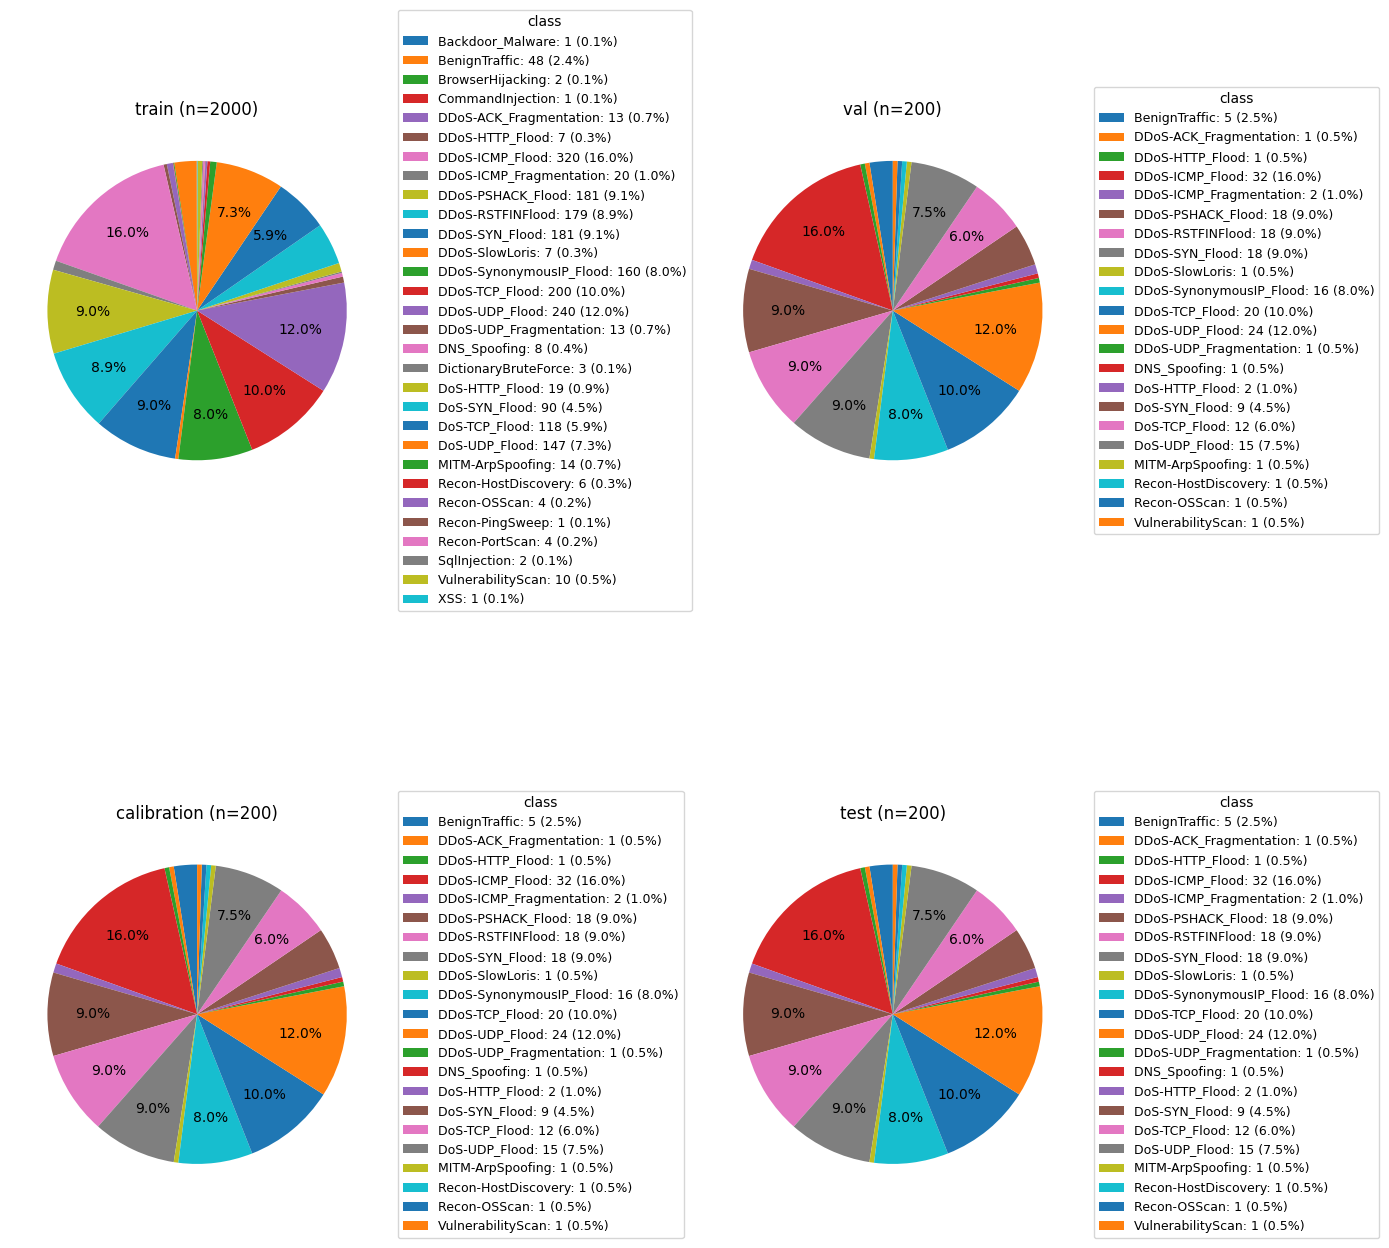

In [21]:
# pie chart
splits = {
    "train": y_train,
    "val": y_val,
    "calibration": y_cal,
    "test": y_test,
}

fig, axes = plt.subplots(2, 2, figsize=(14, 14))
for ax, (name, y) in zip(axes.ravel(), splits.items()):
    plot_class_balance_pie(y, class_names, title=f"{name} (n={len(to_np_x(y))})", ax=ax)

plt.tight_layout()
plt.show()

## Quantum Circuit: Angle Encoding, Data Reuploading, and Adding Noise

$x\xrightarrow[\text{encode}]{\phi(x)}\ket{\psi(x)}\xrightarrow[\text{variational}]{U(\theta)}\ket{\Phi(x)}\xrightarrow{\Lambda_p}\rho(x)$
- $x$: classical data
- $\phi(x)$: `qp.AngleEmbedding()`
- $\ket{\psi(x)}$: quantum state after encoding
- $U(\theta)$: `qp.StronglyEntanglingLayers()`
- $\ket{\Phi(x)}$: quantum state after variational transform
- $\rho(x)=\Lambda_p(\ket{\Phi(x)}\bra{\Phi(x)})$: standard depolarization channel to model NISQ noise

In [22]:
num_layers = 2                  # reupload same classical data
noise_rate = DEFAULT_NOISE_RATE

In [23]:
# initialize device
dev = create_quantum_device(num_qubits)

# define circuit
forward_circuit = build_forward_circuit(dev, num_qubits, num_layers, noise_rate=noise_rate)

# define classifier head
classifier_head = nn.Linear(num_qubits, num_classes).to(device)

In [24]:
# initialize weights
theta = initialize_weights(num_layers, num_qubits, device)
theta.shape

torch.Size([2, 8, 3])

## Training

Training uses **cross-entropy only** (excluding $L_{intra}$ and $L_{inter}$).

$$
L = L_{CE} + \lambda_1 L_{intra} + \lambda_2 L_{inter}
$$

After setting $\lambda_1 = \lambda_2 = 0$,

$$
L = L_{CE}
$$

This is the baseline used to validate that FGSM/PGD degrade accuracy.

Minimizing $L_{CE}$ adjusts $\theta$ for better class predictions.

In [25]:
lambda1 = 0.0   # no intra loss
lambda2 = 0.0   # no inter loss
epochs = 10
batch_size = 256
lr = 0.05
IMBALANCE_MODE = "class_weighted_ce"

In [26]:
# define loss function
ce_loss_fn = nn.CrossEntropyLoss(weight=weight_tensor)
if IMBALANCE_MODE == "class_weighted_ce":
    ce_loss_fn = nn.CrossEntropyLoss(weight=weight_tensor)
elif IMBALANCE_MODE == "weighted_sampler":
    ce_loss_fn = nn.CrossEntropyLoss()
else:
    raise ValueError(f"unknown IMBALANCE_MODE={IMBALANCE_MODE}")

# define optimizer
optimizer = torch.optim.Adam(list([theta]) + list(classifier_head.parameters()), lr=lr)

# no PrototypeBank for plain VQC training

In [27]:
history = {"loss": [], "l_ce": [], "val_macro_f1": [], "epoch_sec": []}

num_batches = (len(X_train) + batch_size - 1) // batch_size
print(f"plain VQC training: {len(X_train)} samples, {num_batches} batches/epoch, {epochs} epochs")

train_t0 = time.perf_counter()
for epoch in range(epochs):
    epoch_t0 = time.perf_counter()
    perm = torch.randperm(len(X_train), device=device)
    epoch_loss = []

    for batch_idx, start in enumerate(range(0, len(perm), batch_size)):
        idx = perm[start:start + batch_size]
        X_batch, y_batch = X_train[idx], y_train[idx]

        loss = compute_l_ce(theta, classifier_head, ce_loss_fn, X_batch, y_batch, forward_circuit, device)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss.append(float(loss.item()))
        print(f"epoch {epoch+1} batch {batch_idx}/{num_batches-1}", flush=True)

    history["loss"].append(float(np.mean(epoch_loss)))
    history["l_ce"].append(history["loss"][-1])

    y_true, y_pred = predict_labels(X_val, y_val, theta, classifier_head, forward_circuit, device)
    val_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    history["val_macro_f1"].append(float(val_f1))
    history["epoch_sec"].append(time.perf_counter() - epoch_t0)

    print(
        f"epoch {epoch+1:02d}/{epochs} | loss={history['loss'][-1]:.4f} | "
        f"val_macro_f1={val_f1:.4f} | time={history['epoch_sec'][-1]:.1f}s"
    )

print(f"training done in {(time.perf_counter()-train_t0)/60:.1f} min")
theta_star = theta

plain VQC training: 2000 samples, 8 batches/epoch, 10 epochs
epoch 1 batch 0/7
epoch 1 batch 1/7
epoch 1 batch 2/7
epoch 1 batch 3/7
epoch 1 batch 4/7
epoch 1 batch 5/7
epoch 1 batch 6/7
epoch 1 batch 7/7
epoch 01/10 | loss=2.9640 | val_macro_f1=0.0423 | time=402.8s
epoch 2 batch 0/7
epoch 2 batch 1/7
epoch 2 batch 2/7
epoch 2 batch 3/7
epoch 2 batch 4/7
epoch 2 batch 5/7
epoch 2 batch 6/7
epoch 2 batch 7/7
epoch 02/10 | loss=2.2939 | val_macro_f1=0.0490 | time=403.2s
epoch 3 batch 0/7
epoch 3 batch 1/7
epoch 3 batch 2/7
epoch 3 batch 3/7
epoch 3 batch 4/7
epoch 3 batch 5/7
epoch 3 batch 6/7
epoch 3 batch 7/7
epoch 03/10 | loss=2.1368 | val_macro_f1=0.0594 | time=404.7s
epoch 4 batch 0/7
epoch 4 batch 1/7
epoch 4 batch 2/7
epoch 4 batch 3/7
epoch 4 batch 4/7
epoch 4 batch 5/7
epoch 4 batch 6/7
epoch 4 batch 7/7
epoch 04/10 | loss=2.0288 | val_macro_f1=0.1099 | time=403.6s
epoch 5 batch 0/7
epoch 5 batch 1/7
epoch 5 batch 2/7
epoch 5 batch 3/7
epoch 5 batch 4/7
epoch 5 batch 5/7
epoch 5

In [ ]:
# write log (temporarily after training)
log_path = write_history_log(
    history,
    notebook="12.fgsm-pgd-kaggle.ipynb",
    extra={
        "epochs": epochs,
        "batch_size": batch_size,
        "lr": lr,
        "lambda1": lambda1,
        "lambda2": lambda2,
    },
    log_dir="logs"
)
print(f"wrote {log_path.resolve()}")

wrote /kaggle/working/logs/12.fgsm-pgd-kaggle.log


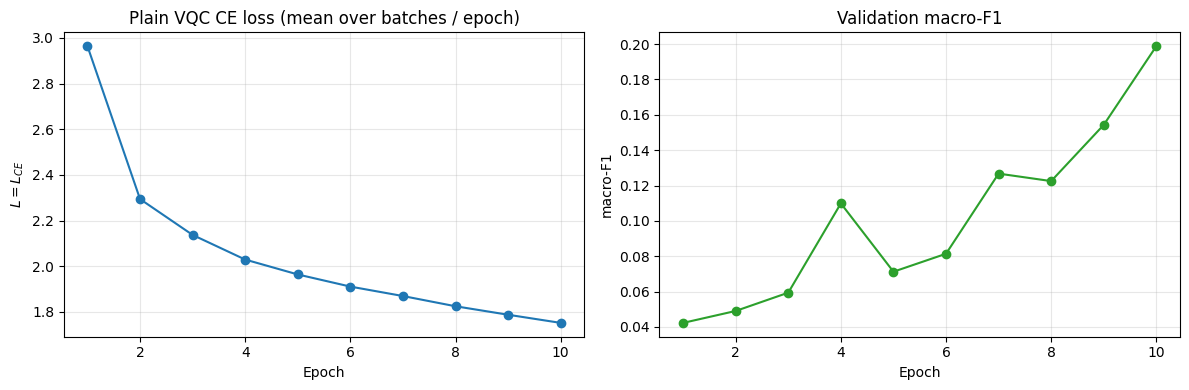

In [29]:
# plots
epochs_x = range(1, len(history["loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_x, history["loss"], marker="o")
axes[0].set_title("Plain VQC CE loss (mean over batches / epoch)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel(r"$L = L_{CE}$")
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_x, history["val_macro_f1"], marker="o", color="tab:green")
axes[1].set_title("Validation macro-F1")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("macro-F1")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Evaluation on Known Test Samples

clean test accuracy: 0.3950
clean test macro-F1: 0.1411
                         precision    recall  f1-score   support

       Backdoor_Malware       0.00      0.00      0.00         0
          BenignTraffic       0.50      0.60      0.55         5
       BrowserHijacking       0.00      0.00      0.00         0
       CommandInjection       0.00      0.00      0.00         0
 DDoS-ACK_Fragmentation       0.50      1.00      0.67         1
        DDoS-HTTP_Flood       0.00      0.00      0.00         1
        DDoS-ICMP_Flood       0.65      1.00      0.79        32
DDoS-ICMP_Fragmentation       1.00      1.00      1.00         2
      DDoS-PSHACK_Flood       0.00      0.00      0.00        18
       DDoS-RSTFINFlood       0.00      0.00      0.00        18
         DDoS-SYN_Flood       0.00      0.00      0.00        18
         DDoS-SlowLoris       0.00      0.00      0.00         1
DDoS-SynonymousIP_Flood       0.00      0.00      0.00        16
         DDoS-TCP_Flood       0.1

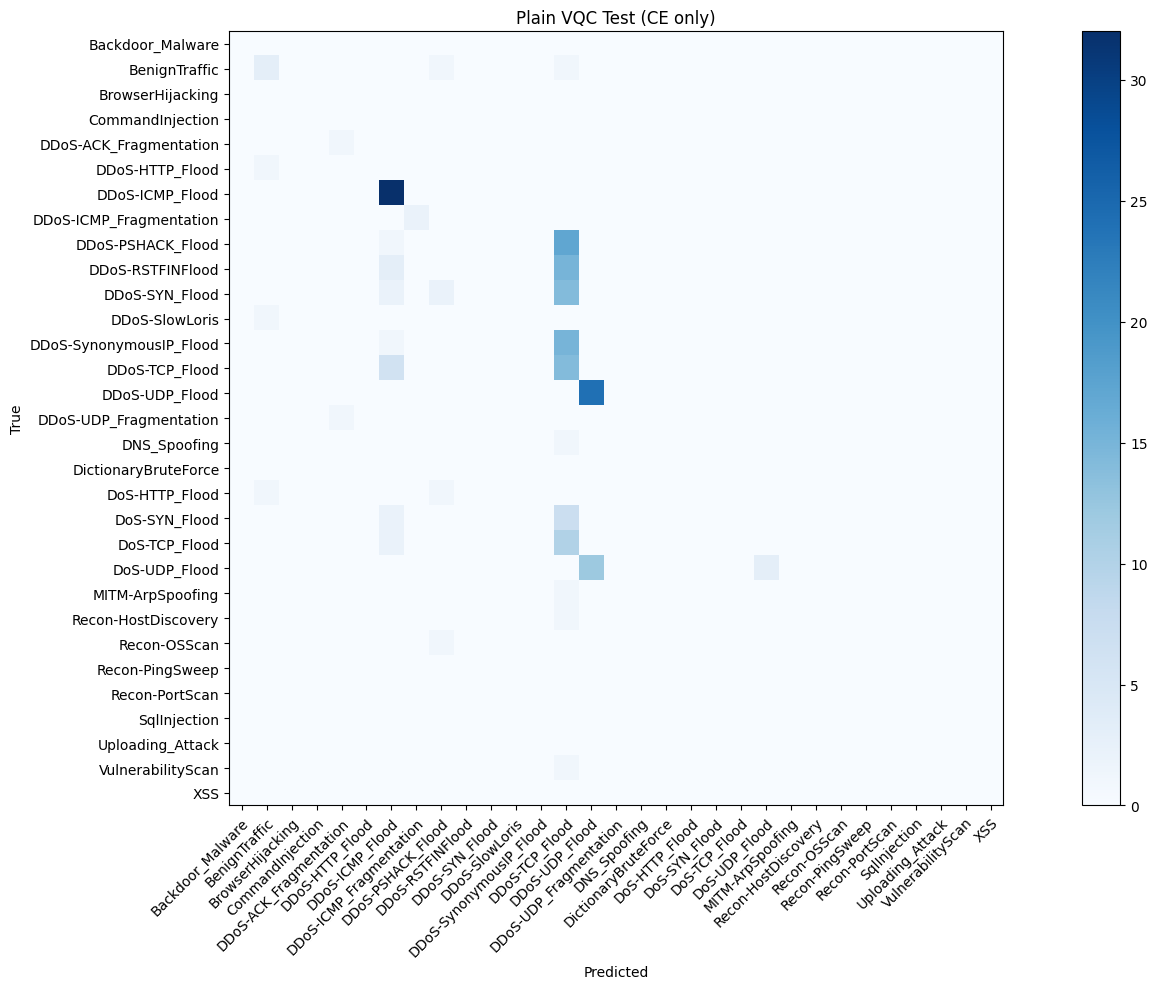

In [30]:
label_ids = list(range(num_classes))

y_true, y_pred = predict_labels(
    X_test, y_test, theta_star, classifier_head, forward_circuit, device
)

clean_acc = float(np.mean(y_true == y_pred))
clean_macro_f1 = float(
    f1_score(y_true, y_pred, average="macro", labels=label_ids, zero_division=0)
)

print(f"clean test accuracy: {clean_acc:.4f}")
print(f"clean test macro-F1: {clean_macro_f1:.4f}")
print(
    classification_report(
        y_true, y_pred,
        labels=label_ids,
        target_names=class_names,
        zero_division=0,
    )
)

cm = confusion_matrix(y_true, y_pred, labels=label_ids)
fig, ax = plt.subplots(figsize=(16, 10))
im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
ax.figure.colorbar(im, ax=ax)
ax.set(
    xticks=np.arange(len(class_names)),
    yticks=np.arange(len(class_names)),
    xticklabels=class_names,
    yticklabels=class_names,
    xlabel="Predicted",
    ylabel="True",
    title="Plain VQC Test (CE only)",
)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
plt.tight_layout()
plt.show()

## Attacks

In [31]:
EPS = 0.2
ALPHA = 0.01
PGD_STEPS = 10

In [32]:
X_atk, y_atk = X_test, y_test

clean = {"acc": clean_acc, "macro_f1": clean_macro_f1}

# include EPS so the snapshot is taken from the same sweep
epsilons = sorted(set([0.0, 0.05, 0.1, 0.15, 0.2, 0.3, float(EPS)]))

fgsm_by_eps, pgd_by_eps = {}, {}

for eps in epsilons:
    if eps == 0.0:
        fgsm_by_eps[eps] = clean
        pgd_by_eps[eps] = clean
        continue

    fgsm_by_eps[eps] = eval_attacked(
        fgsm_attack, X_atk, y_atk,
        theta_star, classifier_head, forward_circuit, device,
        labels=label_ids, eps=eps,
    )
    pgd_by_eps[eps] = eval_attacked(
        pgd_attack, X_atk, y_atk,
        theta_star, classifier_head, forward_circuit, device,
        labels=label_ids, eps=eps, alpha=eps / 5, steps=PGD_STEPS,
    )

In [33]:
# snapshot at configured EPS
fgsm = fgsm_by_eps[float(EPS)]
pgd = pgd_by_eps[float(EPS)]

print("clean :", clean)
print("FGSM  :", {k: fgsm[k] for k in ("acc", "macro_f1")})
print("PGD   :", {k: pgd[k] for k in ("acc", "macro_f1")})
print(f"FGSM drop (acc): {clean['acc'] - fgsm['acc']:+.4f}")
print(f"PGD  drop (acc): {clean['acc'] - pgd['acc']:+.4f}")
print(f"FGSM drop (macro-F1): {clean['macro_f1'] - fgsm['macro_f1']:+.4f}")
print(f"PGD  drop (macro-F1): {clean['macro_f1'] - pgd['macro_f1']:+.4f}")

if clean["acc"] <= 0:
    raise RuntimeError("clean acc is 0: fix data/training before attack check")

fgsm_hurt = (fgsm["acc"] < clean["acc"]) or (fgsm["macro_f1"] < clean["macro_f1"])
pgd_hurt = (pgd["acc"] < clean["acc"]) or (pgd["macro_f1"] < clean["macro_f1"])

if not fgsm_hurt:
    print("WARN: FGSM did not degrade acc/macro-F1 (try larger EPS)")
if not pgd_hurt:
    print("WARN: PGD did not degrade acc/macro-F1 (try larger EPS / more steps)")
if fgsm_hurt and pgd_hurt:
    print("OK: attacks degrade accuracy/F1 vs clean")

clean : {'acc': 0.395, 'macro_f1': 0.14112562069551315}
FGSM  : {'acc': 0.02, 'macro_f1': 0.013594470046082949}
PGD   : {'acc': 0.02, 'macro_f1': 0.015806451612903224}
FGSM drop (acc): +0.3750
PGD  drop (acc): +0.3750
FGSM drop (macro-F1): +0.1275
PGD  drop (macro-F1): +0.1253
OK: attacks degrade accuracy/F1 vs clean


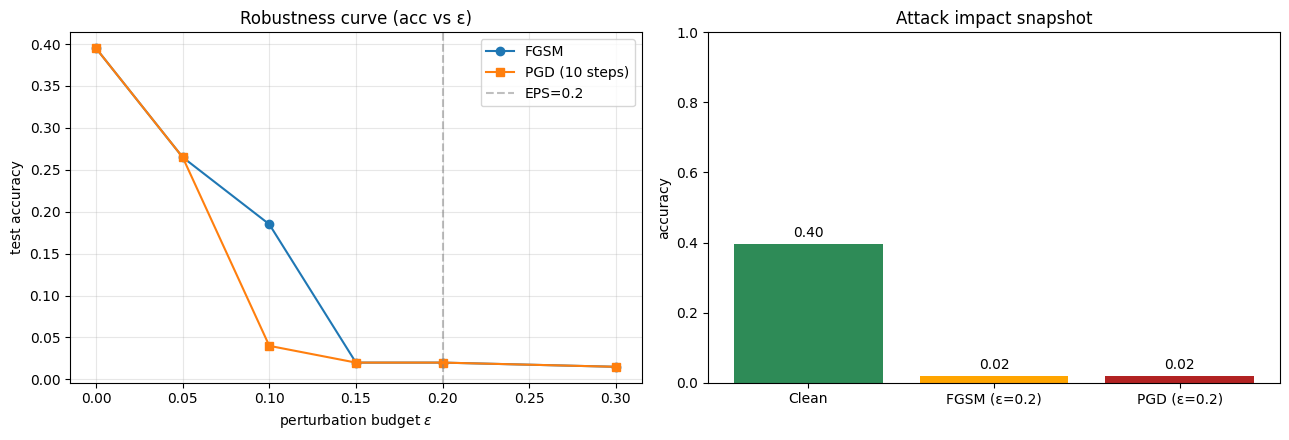

In [34]:
# plots
fgsm_accs = [fgsm_by_eps[e]["acc"] for e in epsilons]
pgd_accs = [pgd_by_eps[e]["acc"] for e in epsilons]

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].plot(epsilons, fgsm_accs, marker="o", label="FGSM")
ax[0].plot(epsilons, pgd_accs, marker="s", label=f"PGD ({PGD_STEPS} steps)")
ax[0].axvline(float(EPS), color="gray", linestyle="--", alpha=0.5, label=f"EPS={EPS}")
ax[0].set_xlabel(r"perturbation budget $\varepsilon$")
ax[0].set_ylabel("test accuracy")
ax[0].set_title("Robustness curve (acc vs ε)")
ax[0].legend()
ax[0].grid(True, alpha=0.3)

bars = ax[1].bar(
    ["Clean", f"FGSM (ε={EPS})", f"PGD (ε={EPS})"],
    [clean["acc"], fgsm["acc"], pgd["acc"]],
    color=["seagreen", "orange", "firebrick"],
)
ax[1].set_ylabel("accuracy")
ax[1].set_ylim(0, 1)
ax[1].set_title("Attack impact snapshot")
for b in bars:
    ax[1].text(
        b.get_x() + b.get_width() / 2,
        b.get_height() + 0.02,
        f"{b.get_height():.2f}",
        ha="center",
    )

plt.tight_layout()
plt.show()

## Logging

In [35]:
for k in history.keys():
    print(k)

loss
l_ce
val_macro_f1
epoch_sec


In [36]:
# write log (final)
log_path = write_history_log(
    history,
    notebook="12.fgsm-pgd-kaggle.ipynb",
    extra={
        "label_column": "label_multiclass",
        "imbalance_mode": IMBALANCE_MODE,

        # plain VQC
        "epochs": epochs,
        "batch_size": batch_size,
        "lr": lr,
        "lambda1": lambda1,
        "lambda2": lambda2,
        "n_train": len(X_train),
        "n_val": len(X_val),
        "n_test": len(X_test),
        "clean_test_acc": clean_acc,
        "clean_test_macro_f1": clean_macro_f1,

        # attacks
        "fgsm_eps": EPS,
        "fgsm_test_acc": fgsm["acc"],
        "fgsm_test_macro_f1": fgsm["macro_f1"],
        "pgd_eps": EPS,
        "pgd_alpha": ALPHA,
        "pgd_steps": PGD_STEPS,
        "pgd_test_acc": pgd["acc"],
        "pgd_test_macro_f1": pgd["macro_f1"],

        "class_names": list(class_names),
    },
    log_dir="logs",
)
print(f"wrote {log_path.resolve()}")

wrote /kaggle/working/logs/12.fgsm-pgd-kaggle.log
